The purpose of this notebook is to generate plots for the OH forced-methane figure we will use as figure 3.

In [1]:
from hydra import compose, initialize
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import xarray as xr
import numpy as np
from pathlib import Path
from methane_noise_forcing.plotting.constants import (
    matplotlib_rcparams,
    fig_width_options,
    colors_vibrant,
)
from methane_noise_forcing.naming import (
    generate_noise_realization_name,
    generate_firn_smoothing_name,
    generate_sample_name,
)
from methane_noise_forcing.noise import solve_ch4_anomaly_lifetime

plt.rcParams.update(matplotlib_rcparams)

In [2]:
## figure settings
fig_width = fig_width_options["two_column_small"]  # inches
ax_height = 1.5  # inches

# load noise

In [3]:
timescales = [0.1, 1, 10, 100]
site_name = "wdc06a"  # wdc05a, wdc06a, gisp2, neem
time_min = 800
time_max = 1800

if (site_name == "wdc05a") or (site_name == "wdc06a"):
    filter_name = "wais"
else:
    filter_name = site_name

instantaneous_noise = {}
smoothed_noise = {}
sampled_noise = {}
for timescale in timescales:
    # resolve paths
    timescale_cfg = timescale
    if timescale == 0.1:
        timescale_cfg = "0-1"
    with initialize(version_base=None, config_path="../../configs"):
        cfg = compose(
            config_name="config",
            overrides=[
                f"+noise=two_timescale_ar1_{timescale_cfg}",
                f"+firn_kernel=firn_model_{filter_name}",
                f"+sampling={site_name}",
            ],
        )
    noise_name = generate_noise_realization_name(cfg)
    firn_name = generate_firn_smoothing_name(cfg)
    sample_name = generate_sample_name(cfg)
    input_dir = Path(cfg.paths.noise_realizations_root)

    # load noise
    instantaneous_noise[timescale] = xr.load_dataset(
        input_dir / noise_name / f"{noise_name}.nc"
    )
    smoothed_noise[timescale] = xr.load_dataset(
        input_dir / noise_name / firn_name / f"smoothed_{noise_name}.nc"
    )
    sampled_noise[timescale] = xr.load_dataset(
        input_dir
        / noise_name
        / firn_name
        / sample_name
        / f"sampled_smoothed_{noise_name}.nc"
    )

    # invert time axis for sampled noise
    sampled_noise[timescale] = sampled_noise[timescale].isel(time=slice(None, None, -1))

    # re-center time axis for continuous noise representations to match sampling
    core_offset = sampled_noise[timescale].time.attrs["core_offset"]
    series_offset = sampled_noise[timescale].time.attrs["series_offset"]
    new_time = instantaneous_noise[timescale].time + core_offset - series_offset
    instantaneous_noise[timescale] = instantaneous_noise[timescale].assign_coords(
        time=new_time
    )
    smoothed_noise[timescale] = smoothed_noise[timescale].assign_coords(time=new_time)

# generate OH-forced noise

In [4]:
# read in OH forcing data
ds = xr.open_dataset(Path(cfg.paths.data_dir) / "oh_forcing" / "oh_forcing.nc")
# extract OH
da_oh_mean = ds["OH"].mean(dim="time")
da_oh_anomaly = ds["OH"] - da_oh_mean
da_oh_anomaly_fraction = da_oh_anomaly / da_oh_mean

# choose appropriate selection
column = "free_trop"
region = "tropical"

oh_mean = da_oh_mean.sel(region=region, column=column).values.item()
oh_anomaly = da_oh_anomaly.sel(region=region, column=column)
oh_anomaly_fraction = da_oh_anomaly_fraction.sel(region=region, column=column)

In [5]:
# choose ch4 mean (for rate constant) and mean lifetime
lifetime_mean = 10 # years
ch4_mean = 650 # ppb
# calculated values
rate_mean = ch4_mean / lifetime_mean  # ppb/year
S_anomaly = -rate_mean * oh_anomaly_fraction  # ppb/year
t_eval = np.arange(3001, 6002, 1) # years

result_anomaly = solve_ch4_anomaly_lifetime(
    t_eval=t_eval,
    C0_anom=0,
    S_anom=(S_anomaly.time.values, S_anomaly.values * 1e-9),
    tau=lifetime_mean,
    max_step=0.1, # year
)

# Assembling full plot

In [6]:
## functions
def format_xticks(ax, direction="in", length_major=4, length_minor=2, show_label=False):
    if not show_label:
        ax.set_xticklabels([])  # 1. no labels
    ax.tick_params(
        axis="x", which="major", direction=direction, length=length_major
    )  # 2. major ticks inside
    ax.xaxis.set_minor_locator(
        plt.MultipleLocator((ax.get_xticks()[1] - ax.get_xticks()[0]) / 2)
    )  # 3. minor ticks halfway
    ax.tick_params(
        axis="x", which="minor", direction=direction, length=length_minor
    )  # minor ticks inside, shorter

def annotate_panel(ax, text, loc="left", pad=0.01, color='k', **kwargs):
    """Place bold text at the top-left/right inside an axis."""
    x = pad if loc == "left" else 1 - pad
    ha = "left" if loc == "left" else "right"
    ax.text(
        x,
        0.98,
        text,
        transform=ax.transAxes,
        ha=ha,
        va="top",
        fontweight="bold",
        color=color,
        **kwargs
    )

def year_label(timescale: float) -> str:
    """Singular/plural label."""
    return "year" if abs(timescale - 1) < 1e-12 else "years"


def timescale_label(letter: str, tau: float) -> str:
    """
    Build '(c) \\boldsymbol{\\tau}_{\\varepsilon} = 10 years'
    (entire string will be bold via annotate_panel; math part bolded via \\boldsymbol)
    """
    return (
        f"({letter}) "
        + r"$\boldsymbol{\tau}_{\varepsilon}$"
        + f" = {tau:g} {year_label(tau)}"
    )

def _sigma_text(val: float) -> str:
    return f"\u03C3\u00A0=\u00A0{val:.1f}"

Text(0.99, 0.05, 'Atmospheric noise-forced')

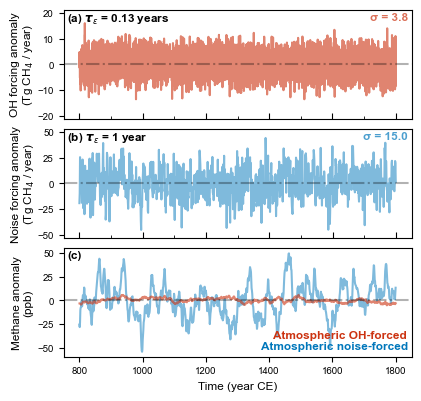

In [7]:
# parameters
ppb_to_Tg = 2.75 # multiplicative conversion from ppb to Tg ch4
oh_fraction_to_Tg_yr = -rate_mean * ppb_to_Tg # multiplicative conversion from fraction anomaly to forcing (Tg ch4/yr)
ylim_oh = (-21, 21) # Tg/yr
yticks_oh = [-20, -10, 0, 10, 20] # Tg/yr
timescale_plot = 1 # years
idx_ens_noise = {0.1: 50, # or 22, 37, 47, 49, 50, 62
                 1: 28, # or 14, 18, 27, 39, 46
                 10: 42, 
                 100: 7}
ylims_noise_forcing = {
    0.1: (-210, 210),
    1: (-52.5, 52.5),
    10: (-21, 21)
}
ylims_noise = {
    0.1: (-210, 210),
    1: (-52.5, 52.5),
    10: (-21, 21)
}
xticks = [800, 1000, 1200, 1400, 1600, 1800]
time_min_oh = 3200 # year
time_max_oh = 4200 # year
time_min_sim = 800 # year
time_max_sim = 1800 # year
plot_kwargs = {
    "noise": {
        "alpha": 0.5,
        "color": colors_vibrant["blue"],
    },
    "oh": {
        "alpha": 0.6,
        "color": colors_vibrant["red"],
    }
}

fig = plt.figure(figsize=(fig_width, 3 * ax_height))
gs = GridSpec(
    nrows=3,
    ncols=1,
    figure=fig,
    hspace=0.1
)

## top plot: OH forcing
ax_oh = fig.add_subplot(gs[0, 0])
# subset and transform time axis to match
oh_anomaly_plot = oh_anomaly_fraction.sel(time=slice(time_min_oh, time_max_oh))
time_oh = oh_anomaly_plot.time.values - time_min_oh + time_min_sim
ax_oh.plot(time_oh, 
           oh_anomaly_plot * oh_fraction_to_Tg_yr, 
           **plot_kwargs["oh"])
ax_oh.axhline(0, color="k", linestyle="-.", alpha=0.3)
ax_oh.set_ylabel("OH forcing anomaly\n(Tg CH$_4$ / year)", labelpad=1)
ax_oh.set_ylim(ylim_oh)
ax_oh.set_yticks(yticks_oh)
ax_oh.set_xticks(xticks)
format_xticks(ax_oh)

## middle plot: noise forcing
ax_noise = fig.add_subplot(gs[1, 0])
forcing_plot = instantaneous_noise[timescale_plot]["forcing"].sel(ensemble=idx_ens_noise[timescale_plot], time=slice(time_min_sim, time_max_sim))
ax_noise.plot(forcing_plot.time, forcing_plot * ppb_to_Tg, **plot_kwargs["noise"])
ax_noise.axhline(0, color="k", linestyle="-.", alpha=0.3)
ax_noise.set_ylabel("Noise forcing anomaly\n(Tg CH$_4$ / year)", labelpad=0)
ax_noise.set_ylim(ylims_noise_forcing[timescale_plot])
# ax_noise.set_yticks(yticks_noise)
ax_noise.set_xticks(xticks)
format_xticks(ax_noise)

## bottom plot: methane concentrations
ax_methane = fig.add_subplot(gs[2, 0])
# plot noise-driven simulation
noise_plot = instantaneous_noise[timescale_plot]["ch4"].sel(ensemble=idx_ens_noise[timescale_plot], time=slice(time_min_sim, time_max_sim))
ax_methane.plot(noise_plot.time, noise_plot, **plot_kwargs["noise"])
mask = (result_anomaly.t > time_min_oh) & (result_anomaly.t <= time_max_oh)
ax_methane.plot(
    result_anomaly.t[mask] - time_min_oh + time_min_sim, 
    result_anomaly.C[mask] * 1e9, 
    **plot_kwargs["oh"]
)
ax_methane.axhline(0, color="k", linestyle="-.", alpha=0.3)
ax_methane.set_ylabel("Methane anomaly\n(ppb)", labelpad=3)
ax_methane.set_xlabel("Time (year CE)")

## annotations
annotate_panel(ax_oh, timescale_label("a", 0.13), loc="left", color='k')
annotate_panel(ax_noise, timescale_label("b", timescale_plot), loc="left", color='k')
annotate_panel(ax_methane, "(c)", loc="left", color='k')

# standard deviations
annotate_panel(
    ax_oh, 
    _sigma_text((oh_anomaly_plot * oh_fraction_to_Tg_yr).std(ddof=1)), 
    loc="right", 
    color=plot_kwargs["oh"]["color"],
    alpha=0.7
)
annotate_panel(
    ax_noise, 
    _sigma_text((forcing_plot * ppb_to_Tg).std(ddof=1)), 
    loc="right", 
    color=plot_kwargs["noise"]["color"],
    alpha=0.7
)

# legend (bottom right corner of last row)
legend_x = 0.99
legend_y_start = 0.05
legend_dy = 0.1
ax_methane.text(
    legend_x - 0.003,
    legend_y_start + legend_dy,
    "Atmospheric OH-forced",
    color=plot_kwargs["oh"]["color"],
    fontweight="bold",
    ha="right",
    va="bottom",
    transform=ax_methane.transAxes,
)
ax_methane.text(
    legend_x,
    legend_y_start,
    "Atmospheric noise-forced",
    color=plot_kwargs["noise"]["color"],
    fontweight="bold",
    ha="right",
    va="bottom",
    transform=ax_methane.transAxes,
)

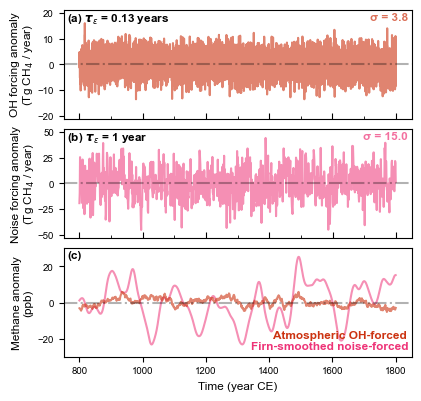

In [8]:
# parameters
ppb_to_Tg = 2.75 # multiplicative conversion from ppb to Tg ch4
oh_fraction_to_Tg_yr = -rate_mean * ppb_to_Tg # multiplicative conversion from fraction anomaly to forcing (Tg ch4/yr)
ylim_oh = (-21, 21) # Tg/yr
yticks_oh = [-20, -10, 0, 10, 20] # Tg/yr
timescale_plot = 1 # years
idx_ens_noise = {0.1: 50, # or 22, 37, 47, 49, 50, 62
                 1: 28, # or 14, 18, 27, 39, 46
                 10: 42, 
                 100: 7}
ylims_noise_forcing = {
    0.1: (-210, 210),
    1: (-52.5, 52.5),
    10: (-21, 21)
}
ylims_noise = {
    0.1: (-210, 210),
    1: (-52.5, 52.5),
    10: (-21, 21)
}
ylim_methane = (-30, 30)
xticks = [800, 1000, 1200, 1400, 1600, 1800]
time_min_oh = 3200 # year
time_max_oh = 4200 # year
time_min_sim = 800 # year
time_max_sim = 1800 # year
plot_kwargs = {
    "noise": {
        "color": colors_vibrant["magenta"],
        "alpha": 0.55,
    },
    "oh": {
        "alpha": 0.6,
        "color": colors_vibrant["red"],
    }
}

fig = plt.figure(figsize=(fig_width, 3 * ax_height))
gs = GridSpec(
    nrows=3,
    ncols=1,
    figure=fig,
    hspace=0.1
)

## top plot: OH forcing
ax_oh = fig.add_subplot(gs[0, 0])
# subset and transform time axis to match
oh_anomaly_plot = oh_anomaly_fraction.sel(time=slice(time_min_oh, time_max_oh))
time_oh = oh_anomaly_plot.time.values - time_min_oh + time_min_sim
ax_oh.plot(time_oh, 
           oh_anomaly_plot * oh_fraction_to_Tg_yr, 
           **plot_kwargs["oh"])
ax_oh.axhline(0, color="k", linestyle="-.", alpha=0.3)
ax_oh.set_ylabel("OH forcing anomaly\n(Tg CH$_4$ / year)", labelpad=1)
ax_oh.set_ylim(ylim_oh)
ax_oh.set_yticks(yticks_oh)
ax_oh.set_xticks(xticks)
format_xticks(ax_oh)

## middle plot: noise forcing
ax_noise = fig.add_subplot(gs[1, 0])
forcing_plot = instantaneous_noise[timescale_plot]["forcing"].sel(ensemble=idx_ens_noise[timescale_plot], time=slice(time_min_sim, time_max_sim))
ax_noise.plot(forcing_plot.time, forcing_plot * ppb_to_Tg, **plot_kwargs["noise"])
ax_noise.axhline(0, color="k", linestyle="-.", alpha=0.3)
ax_noise.set_ylabel("Noise forcing anomaly\n(Tg CH$_4$ / year)", labelpad=0)
ax_noise.set_ylim(ylims_noise_forcing[timescale_plot])
# ax_noise.set_yticks(yticks_noise)
ax_noise.set_xticks(xticks)
format_xticks(ax_noise)

## bottom plot: methane concentrations
ax_methane = fig.add_subplot(gs[2, 0])
# plot noise-driven simulation
# noise_plot = instantaneous_noise[timescale_plot]["ch4"].sel(ensemble=idx_ens_noise[timescale_plot], time=slice(time_min_sim, time_max_sim))
noise_plot = smoothed_noise[timescale_plot]["ch4"].sel(ensemble=idx_ens_noise[timescale_plot], time=slice(time_min_sim, time_max_sim))
ax_methane.plot(noise_plot.time, noise_plot, **plot_kwargs["noise"])
mask = (result_anomaly.t > time_min_oh) & (result_anomaly.t <= time_max_oh)
ax_methane.plot(
    result_anomaly.t[mask] - time_min_oh + time_min_sim, 
    result_anomaly.C[mask] * 1e9, 
    **plot_kwargs["oh"]
)
ax_methane.axhline(0, color="k", linestyle="-.", alpha=0.3)
ax_methane.set_ylim(ylim_methane)
ax_methane.set_ylabel("Methane anomaly\n(ppb)", labelpad=3)
ax_methane.set_xlabel("Time (year CE)")

## annotations
annotate_panel(ax_oh, timescale_label("a", 0.13), loc="left", color='k')
annotate_panel(ax_noise, timescale_label("b", timescale_plot), loc="left", color='k')
annotate_panel(ax_methane, "(c)", loc="left", color='k')

# standard deviations
annotate_panel(
    ax_oh, 
    _sigma_text((oh_anomaly_plot * oh_fraction_to_Tg_yr).std(ddof=1)), 
    loc="right", 
    color=plot_kwargs["oh"]["color"],
    alpha=0.7
)
annotate_panel(
    ax_noise, 
    _sigma_text((forcing_plot * ppb_to_Tg).std(ddof=1)), 
    loc="right", 
    color=plot_kwargs["noise"]["color"],
    alpha=0.7
)

# legend (bottom right corner of last row)
legend_x = 0.99
legend_y_start = 0.05
legend_dy = 0.1
ax_methane.text(
    legend_x - 0.003,
    legend_y_start + legend_dy,
    "Atmospheric OH-forced",
    color=plot_kwargs["oh"]["color"],
    fontweight="bold",
    ha="right",
    va="bottom",
    transform=ax_methane.transAxes,
)
ax_methane.text(
    legend_x,
    legend_y_start,
    "Firn-smoothed noise-forced",
    color=plot_kwargs["noise"]["color"],
    fontweight="bold",
    ha="right",
    va="bottom",
    transform=ax_methane.transAxes,
)

# save figure in pdf format
name = "fig_3"
fig.savefig(
    f"{cfg.paths.figures_dir}/for_publication/{name}.png", bbox_inches="tight", dpi=300
)